In [1]:
# 1. Importar herramientas principales
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 2. Descargar historia de precios de Disney (DIS) del Q1 2023
disney = yf.download(tickers='DIS', start='2023-01-01', end='2023-04-01', rounding=True)

# 3. Extraer solo el precio de cierre y ajustar el índice
disney = disney[['Close']]
disney.index = pd.to_datetime(disney.index)

# 4. Inspeccionar la salud de nuestros datos
print(disney.head())
print(disney.info())

[*********************100%***********************]  1 of 1 completed

Price       Close
Ticker        DIS
Date             
2023-01-03  86.92
2023-01-04  89.86
2023-01-05  89.81
2023-01-06  91.76
2023-01-09  92.59
<class 'pandas.DataFrame'>
DatetimeIndex: 62 entries, 2023-01-03 to 2023-03-31
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   (Close, DIS)  62 non-null     float64
dtypes: float64(1)
memory usage: 992.0 bytes
None


In [2]:
# 1. Calcular el índice exacto para el corte del 70%
limite = int(len(disney) * 0.7)

# 2. Particionar la serie en Entrenamiento y Prueba
train = disney.iloc[:limite]
test = disney.iloc[limite:]

# 3. Validar el tamaño de nuestros nuevos conjuntos
print("Días para Entrenamiento:", len(train))
print("Días para Prueba:", len(test))

Días para Entrenamiento: 43
Días para Prueba: 19


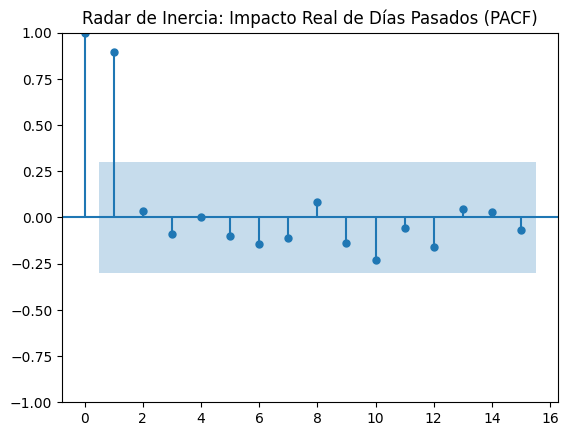

Auditoría de Modelos (Buscamos el BIC más bajo):
Modelo AR(0): BIC = 282.76
Modelo AR(1): BIC = 182.43


C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information an

Modelo AR(2): BIC = 185.49
Modelo AR(3): BIC = 189.05


C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information an

Modelo AR(4): BIC = 192.73


C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Modelo AR(5): BIC = 193.22


In [4]:
# 1. Importar herramientas de gráficos y evaluación de modelos
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# 2. Graficar la Autocorrelación Parcial (PACF) para los datos de entrenamiento
plot_pacf(train, lags=15)
plt.title("Radar de Inercia: Impacto Real de Días Pasados (PACF)")
plt.show()

# 3. Evaluar el Criterio de Información Bayesiano (BIC) para opciones del 0 al 5
print("Auditoría de Modelos (Buscamos el BIC más bajo):")
for p in range(6):
    modelo = ARIMA(train, order=(p, 0, 0))
    resultados = modelo.fit()
    print(f"Modelo AR({p}): BIC = {resultados.bic:.2f}")

In [5]:
# 1. Entrenar el modelo AR(1) definitivo con los datos de entrenamiento
modelo_final = ARIMA(train, order=(1, 0, 0))
resultados_finales = modelo_final.fit()

# 2. Generar pronósticos puntuales para los 19 días de prueba
pronosticos = resultados_finales.forecast(steps=len(test))

# 3. Extraer los intervalos de confianza al 90% (alpha=0.10)
intervalos = resultados_finales.get_forecast(steps=len(test)).conf_int(alpha=0.10)

# 4. Calcular métricas de error (RMSE y MAPE) importando numpy
import numpy as np
rmse = np.sqrt(np.mean((test.values.flatten() - pronosticos.values)**2))
mape = np.mean(np.abs((test.values.flatten() - pronosticos.values) / test.values.flatten())) * 100

# 5. Imprimir el diagnóstico de negocio
print(f"Desfase promedio (RMSE): ${rmse:.2f} USD")
print(f"Margen de error (MAPE): {mape:.2f}%")

Desfase promedio (RMSE): $4.89 USD
Margen de error (MAPE): 4.78%


C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer

C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Yamil\anaconda3\envs\mi_entorno\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer

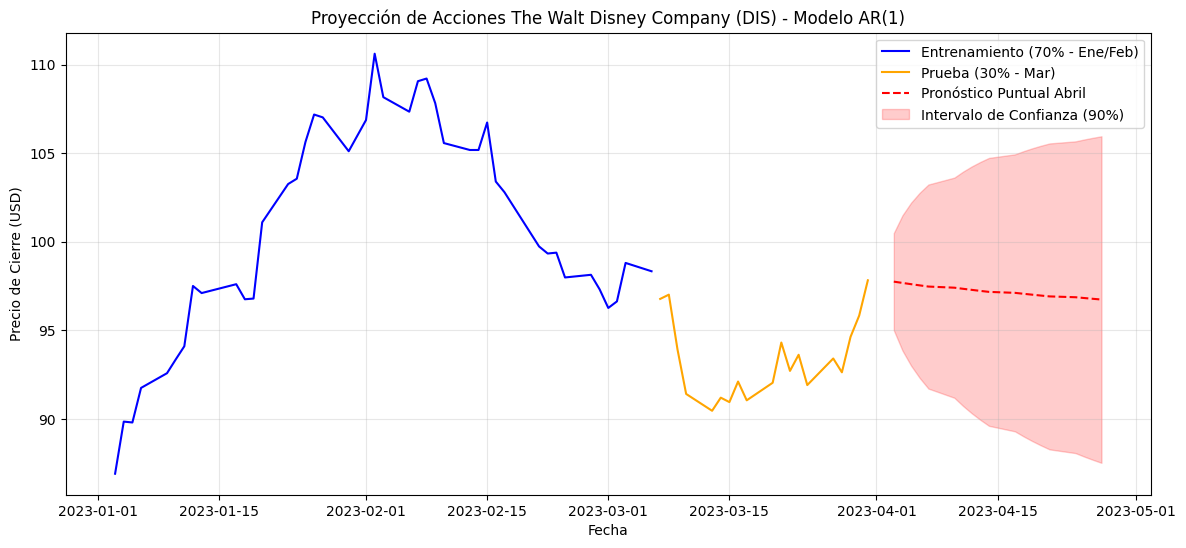

In [6]:
# 1. Entrenar el modelo con TODA la data histórica (Enero - Marzo)
modelo_abril = ARIMA(disney, order=(1, 0, 0))
resultados_abril = modelo_abril.fit()

# 2. Generar pronósticos puntuales para 19 días hábiles de Abril 2023
dias_abril = 19
pronostico_abril = resultados_abril.forecast(steps=dias_abril)

# 3. Extraer los intervalos de confianza al 90% (alpha=0.10)
intervalos_abril = resultados_abril.get_forecast(steps=dias_abril).conf_int(alpha=0.10)

# 4. Asignar fechas reales de Abril a nuestras predicciones
fechas_abril = pd.date_range(start='2023-04-03', periods=dias_abril, freq='B')
pronostico_abril.index = fechas_abril
intervalos_abril.index = fechas_abril

# 5. Graficar los resultados con colores claros para el entregable
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Entrenamiento (70% - Ene/Feb)', color='blue')
plt.plot(test.index, test, label='Prueba (30% - Mar)', color='orange')
plt.plot(pronostico_abril.index, pronostico_abril, label='Pronóstico Puntual Abril', color='red', linestyle='--')

# 6. Sombra del intervalo de confianza al 90%
plt.fill_between(pronostico_abril.index, 
                 intervalos_abril.iloc[:, 0], 
                 intervalos_abril.iloc[:, 1], 
                 color='red', alpha=0.2, label='Intervalo de Confianza (90%)')

plt.title('Proyección de Acciones The Walt Disney Company (DIS) - Modelo AR(1)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()